一、模糊回归：X_reg.
二、X_eval:所有指标

In [4]:
import pandas as pd
import numpy as np
import sys
import os
from sklearn.linear_model import LinearRegression

project_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(project_path)
from models.mohu_model import IterativeMohuDecision
from models.model_validation import validate_fuzzy_model,plot_conf_grid_search,compare_conf_effect
from models.entropy_fce import fit_conf_with_grid_search
from models.decision_engine import DecisionEngine

# from models.sensitivity_sigma import sensitivity_analysis


In [6]:
df = pd.read_excel('../data/city_all_7.xlsx')
# df_2023 = df[df['year'] == 2023]
df_2023 = df.copy()


In [7]:
df_2023 = df_2023.dropna(axis=1, how='all')
df_2023 = df_2023.loc[:, ~df_2023.columns.str.contains('^Unnamed')]

In [8]:
missing_before = df_2023.isnull().sum()
total_missing = missing_before.sum()
print(missing_before[missing_before > 0])
print(f"Total missing values: {total_missing}")

inno            6
rd_gdp         56
rd_people      57
tech_cai        3
edu_cai         3
third_gdp       2
per_gdp         2
goods_gdp       3
growth_gdp      2
qiye            9
student        26
first_gdp       2
second_gdp      2
bed            11
internation    31
loan            2
city_rate       2
dtype: int64
Total missing values: 219


In [9]:
if total_missing == 0:
            print("未发现缺失值，无需填充。")
else:
            # 4. 执行均值填充 (Mean Imputation)
            # select_dtypes(include=[np.number]) 确保只对数值型列进行均值填充，避免对城市名等文本列报错
    numeric_cols = df_2023.select_dtypes(include=[np.number]).columns
    print(f"\n正在对以下数值列进行均值填充：{list(numeric_cols)}")
            
            # 计算均值并填充
            # fillna(df.mean()) 会自动计算每一列的均值并填充该列的缺失值
    df_2023[numeric_cols] = df_2023[numeric_cols].fillna(df_2023[numeric_cols].mean())
            
            # 5. 验证填充结果
    missing_after = df_2023.isnull().sum()
    total_missing_after = missing_after.sum()
            
    print(f"\n--- 填充后验证 ---")
    if total_missing_after == 0:
        print("成功：所有数值型缺失值已使用均值填充完毕。")
    else:            
        print("警告：仍有部分缺失值未处理（可能是非数值型列）。")
        print(missing_after[missing_after > 0])


正在对以下数值列进行均值填充：['year', 'inno', 'rd_gdp', 'rd_people', 'tech_cai', 'edu_cai', 'third_gdp', 'per_gdp', 'goods_gdp', 'growth_gdp', 'qiye', 'student', 'first_gdp', 'second_gdp', 'bed', 'internation', 'loan', 'city_rate']

--- 填充后验证 ---
成功：所有数值型缺失值已使用均值填充完毕。


In [10]:
df_2023.reset_index(drop=True, inplace=True)
df_2023.isnull().sum()

year           0
city           0
inno           0
rd_gdp         0
rd_people      0
tech_cai       0
edu_cai        0
third_gdp      0
per_gdp        0
goods_gdp      0
growth_gdp     0
qiye           0
student        0
first_gdp      0
second_gdp     0
bed            0
internation    0
loan           0
city_rate      0
dtype: int64

In [11]:
X = df_2023.drop(columns=['city', 'year', 'inno']).values
y = df_2023['inno'].values
city_names = df_2023["city"].tolist()
X = X.astype(float)
y = y.astype(float)

In [12]:
#标准化
X_mean,X_std = X.mean(axis=0),X.std(axis=0)
y_mean, y_std = y.mean(), y.std()

X = (X - X_mean) / X_std
y = (y - y_mean) / y_std

##### σ 敏感性分析（插入位置：原始数据提取后、标准化前）──

In [13]:
# # X、y 此时是原始未标准化数据，与函数要求一致
# df_metrics, df_coef = sensitivity_analysis(X, y, sigma_list=[0.5, 1.0, 1.5, 2.0])

# df_metrics.to_excel("../data/sensitivity_metrics.xlsx", index=False)
# df_coef.to_excel("../data/sensitivity_coef.xlsx",       index=False)
# # 在 sensitivity_analysis 调用之后加入以下代码
# best_idx = df_metrics["RMSE"].idxmin()
# best_sigma = df_metrics.loc[best_idx, "σ"]
# print(f"最优 σ = {best_sigma}")
# # 用最优 σ 重新训练模型
# from models.sensitivity_sigma import IterativeMohuWithSigma
# m, n = X.shape
# best_model = IterativeMohuWithSigma(n, m, sigma=best_sigma)
# best_model.setdatax(X)
# best_model.setdatay(y)
# best_model.beta = np.linalg.lstsq(
#     np.hstack([np.ones((m,1)), X]), y, rcond=None
# )[0]
# best_beta = best_model.fit()
# print("最优 σ 下的回归系数：", best_beta)

In [14]:
X_reg = X.copy()
X_eval = X.copy()

In [15]:
print(X_reg[:5])

[[-0.35457826 -0.42682792 -0.81163862  0.39903884 -0.5198399  -0.65426074
  -0.63039316 -0.15996357 -0.53422831 -0.66637989  0.20921631  0.26436795
   0.28057167  0.14714489 -0.4242626  -0.78421297]
 [-0.12207278 -0.23144044  0.33236878  0.33589459 -0.19473918 -0.2360893
  -0.37177915 -0.5461979  -0.21434287 -0.45306632 -0.29446824  0.3829285
  -0.04632455 -0.25047277 -0.25823872 -0.44563502]
 [-0.23550117 -0.44553305  0.29141569  0.96354499  0.417074   -0.79134971
  -0.65177885  0.4966348  -0.85061064 -0.62169076  0.7253683  -0.91249126
  -0.1766216  -1.3061024  -0.39771346 -0.65456058]
 [ 0.10585531 -0.20407059 -0.07639666  0.92533669 -0.20193698 -0.76554112
  -0.5783957  -1.2457112  -0.46756602 -0.0797882  -0.27826057  0.3839003
  -0.6275501  -0.39695066 -0.32286441 -0.60121789]
 [-0.183689   -0.4946879  -0.85316582 -1.19496564  0.41587436 -0.41758461
   0.34270394 -1.44741135 -0.30333647 -0.54866122 -0.68843932  0.19439779
   0.48721636  0.         -0.315955    0.95238812]]


In [16]:
# indicator_type = auto_indicator_type(X.shape[1]) 
# print("Indicator types:", indicator_type)
indicator_type = [1,1,1,1,1,1,1,1,1,-1,1,1,1,1,1,1]#由用户输入indicator_type的值。

In [17]:
# 初始化决策引擎
engine = DecisionEngine(
    regression_config={
        "n": X_reg.shape[1],
        "number": X_reg.shape[0],
        "max_iter": 50
        # "sigma": best_sigma  # 使用最优 σ
    },
    indicator_type=indicator_type
)

In [18]:
result = engine.full_decision(
    X_eval=X_eval,
    X_reg=X_reg,
    y_reg=y,
    city_names=city_names,
    conf_mode='discrete'
)



开始网格搜索（conf_conflict）

[Conf调节] 权重调整效果:
  原始权重: [0.10733359 0.18506524 0.10074423 0.01764401 0.01478361]...
  调整后权重: [0.01405516 0.24233997 0.13192296 0.02310455 0.00193589]...

conf_conflict = 0.1
  Spearman = 0.7780
  STD      = 0.0792
  CV       = 0.3541
  Range    = 0.5880

[Conf调节] 权重调整效果:
  原始权重: [0.10733359 0.18506524 0.10074423 0.01764401 0.01478361]...
  调整后权重: [0.02717583 0.23428364 0.12753732 0.02233646 0.00374307]...

conf_conflict = 0.2
  Spearman = 0.7797
  STD      = 0.0760
  CV       = 0.3114
  Range    = 0.5665

[Conf调节] 权重调整效果:
  原始权重: [0.10733359 0.18506524 0.10074423 0.01764401 0.01478361]...
  调整后权重: [0.03945219 0.22674571 0.12343389 0.0216178  0.00543395]...

conf_conflict = 0.3
  Spearman = 0.7816
  STD      = 0.0731
  CV       = 0.2776
  Range    = 0.5463

[Conf调节] 权重调整效果:
  原始权重: [0.10733359 0.18506524 0.10074423 0.01764401 0.01478361]...
  调整后权重: [0.05096321 0.21967773 0.11958628 0.02094394 0.00701943]...

conf_conflict = 0.4
  Spearman = 0.7652
  STD      = 

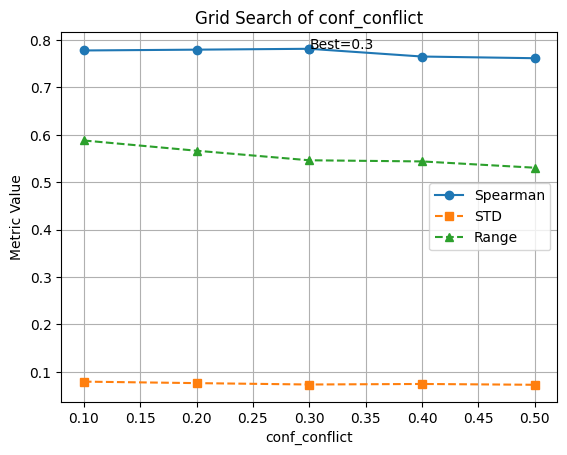

In [19]:
#网格搜索的图
plot_conf_grid_search(result["grid_results"])

In [20]:
print("模糊回归系数：")
print(result["regression_coef"]) 

模糊回归系数：
[-0.04397866 -0.01132891  0.07235844  0.05180269  0.01488124 -1.068447
  0.06266616  0.07020223 -0.00896704 -0.0249756  -0.08472849 -1.04907692
 -1.36177453 -0.02965877  0.00766819  0.663738    0.01935751]


In [21]:
print("语义置信度：")
print(result["semantic_confidence"])
# """语义置信度是用来控制对模糊规则的信任程度的指标，值越高表示对模糊规则的信任越强。
# 只会影响模糊综合评判的隶属度合成、最终等级、排序的稳定性、指标解释的可信程度
# 原本综合隶属度向量：B = W ⊗ R                 现在：B = (W × confidence) ⊗ R
# 不影响预测值（模糊回归）。"""

语义置信度：
[0.3 1.  1.  1.  0.3 1.  1.  0.3 0.3 1.  0.3 0.3 0.3 1.  1.  1. ]


In [22]:
print("熵权：")
print(result["weights"])
print("sum的值为",result["weights"].sum())  # sum必须等于 1
#熵权决定了谁重要，置信度决定了是否应该相信这个重要程度。

熵权：
[0.10733359 0.18506524 0.10074423 0.01764401 0.01478361 0.04443765
 0.14780754 0.00622434 0.06200033 0.00601237 0.04704687 0.01549417
 0.00971754 0.01898715 0.20330306 0.01339829]
sum的值为 1.0


模糊综合评价

In [23]:
#每个城市得分
for i, r in enumerate(result["evaluation"]):
    # print(f"样本 {i}:")
    # print("  等级:", r["grade"])
    # print("  得分:", r["score"])
    print(f"{city_names[i]}得分：{r['score']:.4f}")
    # print(f"{city_names[i]}得分：{r['score']:.4f}。。。反标准化得分:{r['score'] * y_std + y_mean}")  #反标准化得分
    print("  隶属度:", r["membership"])
    

安康市得分：0.2151
  隶属度: [0.05864675 0.03358514 0.0457592  0.08490768 0.77710123]
安庆市得分：0.2501
  隶属度: [0.05490068 0.03803049 0.04408379 0.24504474 0.61794032]
安顺市得分：0.2300
  隶属度: [0.06036711 0.03604836 0.03818113 0.15190911 0.7134943 ]
安阳市得分：0.2347
  隶属度: [0.05268415 0.05137753 0.03032016 0.17300098 0.69261718]
鞍山市得分：0.2355
  隶属度: [0.06166598 0.03923367 0.0223395  0.19321501 0.68354584]
巴彦淖尔市得分：0.2131
  隶属度: [0.05535533 0.02450415 0.03853438 0.13086286 0.75074328]
巴中市得分：0.2049
  隶属度: [0.06552383 0.01453603 0.04429246 0.07184365 0.80380404]
白城市得分：0.2106
  隶属度: [0.05639494 0.02071272 0.03272926 0.13853352 0.75162956]
白山市得分：0.2230
  隶属度: [0.05385242 0.05478812 0.01373098 0.1395089  0.73811958]
白银市得分：0.2135
  隶属度: [0.05222488 0.03710079 0.05727742 0.06989375 0.78350317]
百色市得分：0.2413
  隶属度: [0.05891253 0.02968958 0.03754863 0.22797247 0.64587679]
蚌埠市得分：0.2634
  隶属度: [0.0428697  0.04939235 0.10000834 0.20776102 0.59768074]
包头市得分：0.2511
  隶属度: [0.05849592 0.04850703 0.07762308 0.13681552 0.6785584

In [24]:
for i, r in enumerate(result["evaluation"]):
    if city_names[i] == "北京市":
        print("  北京市的隶属度向量:", r["membership"])

  北京市的隶属度向量: [0.50402701 0.11262442 0.12314313 0.15316414 0.1070413 ]


In [25]:
# 提取得分
scores = np.array([r["score"] for r in result["evaluation"]], dtype=float)

# 均值、标准差
mean_score = scores.mean()
std_score = scores.std()

print("综合得分均值：", round(mean_score, 4))
print("综合得分标准差：", round(std_score, 4))

# 排序取前10
sorted_idx = np.argsort(scores)[::-1]
top10_idx = sorted_idx[:10]

# 前10城市隶属度向量
top10_data = []
for idx in top10_idx:
    city = city_names[idx]
    score = float(result["evaluation"][idx]["score"])
    membership = list(result["evaluation"][idx]["membership"])
    top10_data.append([city, score] + membership)

# 自动生成列名
n_levels = len(top10_data[0]) - 2
# level_names = [f"等级{i+1}" for i in range(n_levels)]
level_names = ["很高", "较高", "中等", "较低", "极低"]
columns = ["城市", "综合得分"] + level_names

df_top10 = pd.DataFrame(top10_data, columns=columns)
print(df_top10)

综合得分均值： 0.2634
综合得分标准差： 0.0731
    城市      综合得分        很高        较高        中等        较低        极低
0  北京市  0.719522  0.504027  0.112624  0.123143  0.153164  0.107041
1  上海市  0.660228  0.302583  0.210519  0.171415  0.305180  0.010302
2  杭州市  0.586744  0.041485  0.323431  0.438892  0.149291  0.046901
3  深圳市  0.553333  0.147158  0.281720  0.243952  0.100802  0.209076
4  苏州市  0.499156  0.061293  0.149229  0.477028  0.127108  0.185342
5  宁波市  0.495791  0.044881  0.098801  0.426825  0.429493  0.000000
6  成都市  0.481814  0.040768  0.106911  0.414742  0.383663  0.053917
7  广州市  0.471450  0.053015  0.253936  0.234956  0.207108  0.250985
8  东莞市  0.460697  0.061947  0.158556  0.192957  0.493726  0.092813
9  重庆市  0.453337  0.050126  0.064964  0.433878  0.307230  0.143801


验证模糊回归模型

In [26]:
# import pandas as pd
# import numpy as np
# import sys
# import os
# from sklearn.linear_model import LinearRegression

# project_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
# sys.path.append(project_path)
# from models.model_validation import validate_fuzzy_model


In [27]:
# df_full = pd.read_excel('../data/city_data.xlsx')
# y_full = df_full["inno"].values
# X_full = df_full.drop(columns=["year", "city", "inno"]).values

# # 对所有年份的数据进行标准化 (与 mohu_data.ipynb 保持一致)
# X_full_mean, X_full_std = X_full.mean(axis=0), X_full.std(axis=0)
# y_full_mean, y_full_std = y_full.mean(), y_full.std()

# X_full_scaled = (X_full - X_full_mean) / X_full_std
# y_full_scaled = (y_full - y_full_mean) / y_full_std

In [28]:
# 2. 获取已训练的模糊回归模型
# X_reg 和 y_reg 是上面的 X_full_scaled 和 y_full_scaled
fuzzy_model_trained = engine.regression
# fuzzy_model_trained = IterativeMohuDecision(n=X_reg.shape[1], number=X_reg.shape[0], max_iter=50)

#创建标准的 OLS 模型用于对比
ols_model = LinearRegression()

In [29]:
#重新加载mohu_model.py
%reload_ext autoreload
%autoreload 2
%matplotlib inline

In [30]:
#3. 执行验证 
from models.model_validation import validate_fuzzy_model

validation_results = validate_fuzzy_model(
    # X=X_full_scaled, 
    # y=y_full_scaled, 
    X=X_reg,
    y=y,
    fuzzy_model=fuzzy_model_trained, 
    ols_model=ols_model
)
for key, value in validation_results.items():
    print(f"{key}: {value:.4f}")

RMSE_fuzzy: 0.3729
RMSE_OLS: 0.2779
RMSE_Huber: 0.3429
RMSE_Ridge: 0.2781
R2_fuzzy: 0.8609
R2_OLS: 0.9227
R2_Huber: 0.8824
R2_Ridge: 0.9227
Spearman_fuzzy: 0.8333
Spearman_TOPSIS: 0.5177
Spearman_OLS: 0.7518
Spearman_Huber: 0.8431
Spearman_Ridge: 0.7531
delta_fuzzy: 0.1481
delta_OLS: 16.0681
delta_Huber: 0.6655
delta_Ridge: 1.2200


In [31]:
import numpy as np
from sklearn.linear_model import LinearRegression, HuberRegressor, Ridge

def add_outliers(X, y, ratio=0.2, scale=5, random_state=42):
    np.random.seed(random_state)
    y_new = y.copy()
    n_outliers = int(len(y) * ratio)
    idx = np.random.choice(len(y), n_outliers, replace=False)
    y_new[idx] += scale * np.std(y)
    return X.copy(), y_new

# 基准系数
beta_base = fuzzy_model_trained.beta.copy()
ols_base = LinearRegression().fit(X_reg, y)
huber_base = HuberRegressor(max_iter=200).fit(X_reg, y)
ridge_base = Ridge(alpha=1.0).fit(X_reg, y)

N_SEEDS = 20
ratios = [0.05, 0.1, 0.2, 0.3]

print("系数稳定性分析（均值 ± 标准差，n=20组随机种子）")
print(f"{'异常比例':<10} {'模糊回归':<22} {'OLS':<22} {'Huber':<22} {'Ridge':<22}")

for r in ratios:
    d_fuzzy, d_ols, d_huber, d_ridge = [], [], [], []
    for seed in range(N_SEEDS):
        X_bad, y_bad = add_outliers(X_reg, y, ratio=r, scale=5, random_state=seed)
        
        # 模糊回归
        fuzzy_model_trained.setdatax(X_bad)
        fuzzy_model_trained.setdatay(y_bad)
        fuzzy_model_trained.setdataxishu(np.zeros(X_reg.shape[1]+1))
        beta_bad = fuzzy_model_trained.fit()
        d_fuzzy.append(np.linalg.norm(beta_base - beta_bad))
        
        # OLS
        ols_bad = LinearRegression().fit(X_bad, y_bad)
        d_ols.append(np.linalg.norm(ols_base.coef_ - ols_bad.coef_))
        
        # Huber
        huber_bad = HuberRegressor(max_iter=200).fit(X_bad, y_bad)
        d_huber.append(np.linalg.norm(huber_base.coef_ - huber_bad.coef_))
        
        # Ridge
        ridge_bad = Ridge(alpha=1.0).fit(X_bad, y_bad)
        d_ridge.append(np.linalg.norm(ridge_base.coef_ - ridge_bad.coef_))
    
    def fmt(arr): return f"{np.mean(arr):.3f}±{np.std(arr):.3f}"
    print(f"{r:.0%}        {fmt(d_fuzzy):<22} {fmt(d_ols):<22} {fmt(d_huber):<22} {fmt(d_ridge):<22}")

系数稳定性分析（均值 ± 标准差，n=20组随机种子）
异常比例       模糊回归                   OLS                    Huber                  Ridge                 
5%        0.649±0.463            13.563±12.023          0.491±0.315            0.334±0.088           
10%        0.737±0.633            17.553±10.895          0.858±0.390            0.437±0.108           
20%        1.009±0.840            30.200±20.271          1.997±1.743            0.603±0.148           
30%        1.183±1.136            31.214±24.916          8.518±9.714            0.717±0.159           


In [32]:
print("base:", beta_base[:5])
print("bad :", beta_bad[:5])

base: [-0.04910846 -0.01119851  0.08800837  0.03868596  0.00898626]
bad : [-0.04852606  0.00012939  0.08351481  0.06176043  0.01582168]


熵权+模糊综合评价模型的验证

In [33]:
from models.model_validation import validate_entropy_fce_model, validate_indicator_weights

In [34]:
# 1. 验证综合评判结果
validation_report = validate_entropy_fce_model(
    evaluation_results=result["evaluation"],
    true_scores=y,
    city_names=df_2023["city"].tolist() 
)
# """
# 排序一致性：Spearman 和 Kendall 系数越接近 1，说明模型的排名与真实排名越一致。
# 区分度：score_std 和 mean_abs_pairwise_diff 越大，说明模型对不同城市的区分能力越强。
# """


=== E-FCE 模型验证: 排名与区分度 ===
得分标准差: 0.0731
得分变异系数(CV): 0.2776
最小非零两两差异: 0.000000
平均绝对两两差异: 0.0657

Top-5 城市:
  1. 北京市 (得分: 0.7195)
  2. 上海市 (得分: 0.6602)
  3. 杭州市 (得分: 0.5867)
  4. 深圳市 (得分: 0.5533)
  5. 苏州市 (得分: 0.4992)

Bottom-5 城市:
  297. 伊春市 (得分: 0.1733)
  296. 四平市 (得分: 0.1806)
  295. 鹤岗市 (得分: 0.1819)
  294. 绥化市 (得分: 0.1916)
  293. 酒泉市 (得分: 0.1940)
Spearman 秩相关系数: 0.7816 (p=0.0000)
Kendall Tau 系数: 0.6155 (p=0.0000)
Pearson 相关系数: 0.8762 (p=0.0000)


In [35]:
full_ranking = validation_report["full_ranking"]
# print("综合评判结果验证：", full_ranking)
print(full_ranking.head(15))
# """真实的排序应该是：
# 深圳
# 北京
# 上海
# 苏州
# 广州

# 杭州
# 武汉                
# 成都

# 南京
# 宁波
# 合肥
# 重庆
# 长沙"""

    City     Score  Rank
17   北京市  0.719522     1
188  上海市  0.660228     2
69   杭州市  0.586744     3
193  深圳市  0.553333     4
202  苏州市  0.499156     5
156  宁波市  0.495791     6
29   成都市  0.481814     7
59   广州市  0.471450     8
44   东莞市  0.460697     9
287  重庆市  0.453337    10
70   合肥市  0.452666    11
49   佛山市  0.437233    12
150  南京市  0.435317    13
213  天津市  0.422146    14
284  郑州市  0.420685    15


In [36]:
# 2. 验证指标权重
validate_indicator_weights(
    weights=result["weights"],
    indicator_names=indicator_type 
)


E-FCE 模型验证: 指标权重分析
[1, 1, 1, 1, 1, 1, 1, 1, 1, -1, 1, 1, 1, 1, 1, 1]
 Indicator   Weight
         1 0.203303
         1 0.185065
         1 0.147808
         1 0.107334
         1 0.100744
         1 0.062000
         1 0.047047
         1 0.044438
         1 0.018987
         1 0.017644
         1 0.015494
         1 0.014784
         1 0.013398
         1 0.009718
         1 0.006224
        -1 0.006012


语义置信度conf的对比


[Baseline] 不使用conf
{'name': 'baseline(no_conf)', 'spearman': 0.7448219031582332, 'p_value': 9.143895720555924e-54, 'std': 0.06548988402237145, 'cv': 0.3036548565651557, 'range': 0.4822633762022231}

[Conf调节] 权重调整效果:
  原始权重: [0.10733359 0.18506524 0.10074423 0.01764401 0.01478361]...
  调整后权重: [0.03945219 0.22674571 0.12343389 0.0216178  0.00543395]...

[Conf] 使用离散conf + 网格搜索
{'name': 'conf(discrete+grid)', 'best_conflict': 0.3, 'spearman': 0.781553204615512, 'p_value': 2.0849024075422207e-62, 'std': 0.07312781259500925, 'cv': 0.27763332611722047, 'range': 0.5462680401168145}


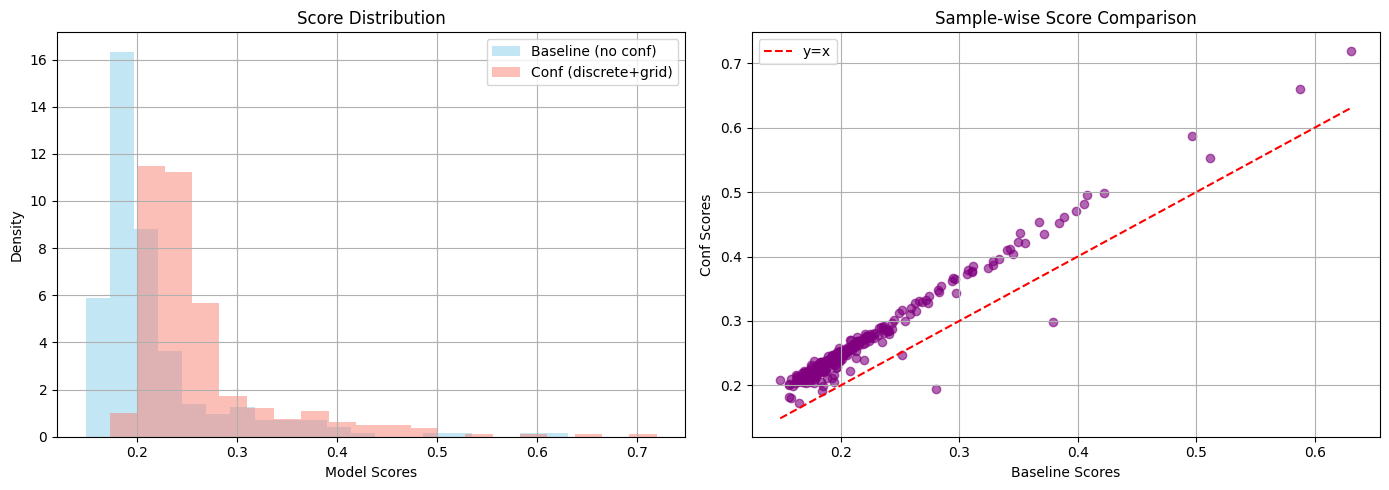

In [39]:
beta = result["regression_coef"][1:]
summary, grid_results = compare_conf_effect(
    model=engine.fce,
    beta=beta,
    indicator_type=engine.fce.indicator_type,
    X=X_eval,
    y_true=y,
    fit_conf_with_grid_search_func=fit_conf_with_grid_search,
    grid_results=result["grid_results"],
    best_param=result["best_param"],
    best_conf=result["best_conf"]
)

In [40]:
df_conf = pd.DataFrame(summary)
print(df_conf)

                  name  spearman       p_value       std        cv     range  \
0    baseline(no_conf)  0.744822  9.143896e-54  0.065490  0.303655  0.482263   
1  conf(discrete+grid)  0.781553  2.084902e-62  0.073128  0.277633  0.546268   

   best_conflict  
0            NaN  
1            0.3  
